<div style="background:#1C3257;color:#F7F3EB;padding:22px 26px;border-radius:10px;font-family:Calibri,Arial,sans-serif"><div style="color:#E08A6E;font-size:12px;letter-spacing:2px;font-weight:bold">MINERÍA DE DATOS · UNIDAD 2 · SEMANA 5 — SESIÓN 2 · UPCh 2026A</div><div style="font-size:26px;font-weight:bold;margin-top:6px">Lab 4 — Descubrimiento de temas con K-Means</div><div style="font-style:italic;color:#C9D4E4;margin-top:8px">Clustering sobre los vectores TF-IDF: el mismo algoritmo de la Unidad 1, sobre texto</div></div>

## Reglas de entrega

- **Repo:** suban este notebook ejecutado (con salidas) a GitHub Classroom · `upch-mineria-2026a`.
- **`AI_USAGE.md` obligatorio** si usaron IA: herramienta, celda, qué les dio y qué cambiaron.
- **Defensa oral (eliminatoria):** se les preguntará por cualquier celda. Si no la pueden explicar, no hay calificación.
- **Tardías:** 25% (<24 h), 50% (<48 h), rechazado (>48 h).
- Lo evaluado son las celdas `# TODO` y las preguntas en **negritas**. El resto es andamiaje ya resuelto.
- **Sin librerías de NLP/IR para resolver:** TF-IDF, BM25, las métricas y K-Means van **desde cero**. `scikit-learn` solo se permite donde se indique *verificación*.


## Objetivo

Sin consulta ni etiquetas, dejar que el corpus revele su estructura temática. Construyen la matriz documento × término con TF-IDF, la normalizan, **reutilizan su K-Means de la Unidad 1** y interpretan los grupos por los términos de mayor peso de cada centroide.


## 0 · Corpus procesado del Lab 1

In [1]:
import json, math, re, unicodedata
from collections import Counter

with open('corpus_procesado.json', encoding='utf-8') as fh:
    corpus = json.load(fh)              # del Lab 1
documentos = [d['tokens'] for d in corpus]
ids = [d['id'] for d in corpus]
print(f'{len(corpus)} documentos. Ejemplo {ids[0]}:', documentos[0][:8])

import numpy as np

14 documentos. Ejemplo d01: ['fuerte', 'lluvia', 'provocar', 'inundación', 'colonia', 'sur', 'tuxtla', 'gutierrez']


## 1 · Matriz documento × término (TF-IDF) + normalización L2

**1.a** Construyan el vocabulario, la matriz densa de pesos TF-IDF (filas = documentos, columnas = términos) y normalicen **cada fila a norma 1**. Reutilicen su `tf`/`idf`/`tfidf` del Lab 2.

In [2]:
import numpy as np

# 1. Traer funciones base del Lab 2
def tf(doc):
    freq = {}
    for term in doc:
        freq[term] = freq.get(term, 0) + 1
    doc_len = len(doc) if len(doc) > 0 else 1
    return {term: count / doc_len for term, count in freq.items()}

def idf(corpus_docs):
    N = len(corpus_docs)
    doc_freq = {}
    for doc in corpus_docs:
        for term in set(doc):
            doc_freq[term] = doc_freq.get(term, 0) + 1
    return {term: math.log(N / df_t) for term, df_t in doc_freq.items()}

def tfidf(doc, idf_dict):
    tf_dict = tf(doc)
    return {term: tf_value * idf_dict.get(term, 0) for term, tf_value in tf_dict.items()}

# 2. Construir Vocabulario y mapeo de columnas
IDF_global = idf(documentos)
vocab = sorted(list(IDF_global.keys()))
col = {termino: idx for idx, termino in enumerate(vocab)}

# 3. Construir la Matriz Densa M con pesos TF-IDF
N_docs = len(documentos)
V_size = len(vocab)
M = np.zeros((N_docs, V_size))

for idx_doc, doc in enumerate(documentos):
    vector_tfidf = tfidf(doc, IDF_global)
    for term, peso in vector_tfidf.items():
        if term in col:
            M[idx_doc, col[term]] = peso

# 4. Normalizar cada FILA a norma L2 -> Mn
normas = np.linalg.norm(M, axis=1, keepdims=True)
# Evitar división por cero en documentos vacíos
normas[normas == 0] = 1.0 
Mn = M / normas

print(f"Matriz construida con éxito. Dimensiones (N x V): {Mn.shape}")

Matriz construida con éxito. Dimensiones (N x V): (14, 199)


> **Pregunta (defensa):** ¿por qué normalizar a L2 antes de agrupar con K-Means? Liguen su respuesta con la similitud coseno de la Sesión 1.


_Su respuesta:_ K-Means tradicional utiliza intrínsecamente la distancia Euclidiana para asignar clusters y recalcular centroides, la normalización L2 fuerza a K-Means a agrupar los documentos basándose estrictamente en la dirección angular de sus vectores de palabras (su temática/proporción de términos) e ignora por completo la longitud absoluta del texto o la verbosidad del documento.

## 2 · Elegir k

**2.a** Usen el **método del codo** (inercia) y el **coeficiente de silueta** para 2 ≤ k ≤ 8. Reutilicen su K-Means de la Unidad 1 para la inercia; la silueta pueden tomarla de scikit-learn (es una métrica, no el algoritmo).

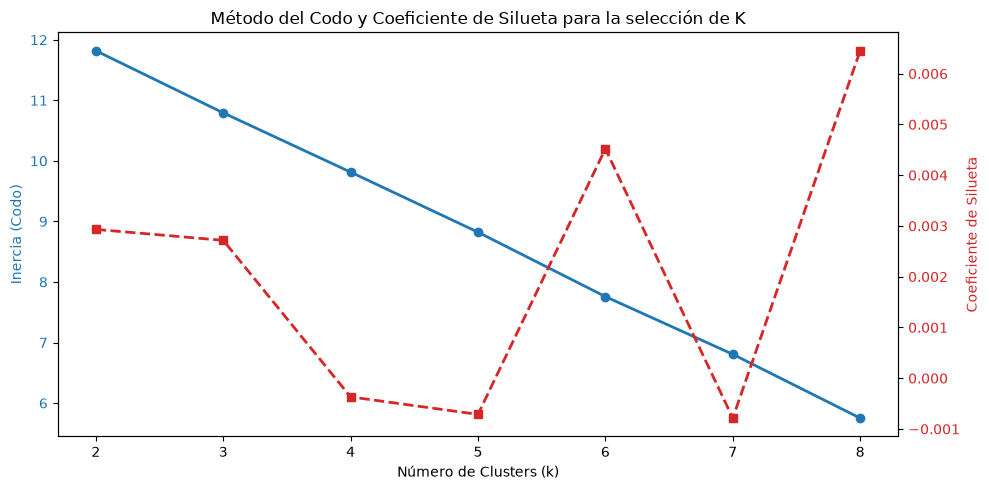

In [3]:
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

# Implementación autocontenida de K-Means desde cero (Unidad 1) adaptada a arrays de numpy
def mi_kmeans(X, k, max_iter=100, seed=42):
    np.random.seed(seed)
    # Inicialización aleatoria Forgy
    indices_iniciales = np.random.choice(X.shape[0], k, replace=False)
    centroides = X[indices_iniciales].copy()
    
    for _ in range(max_iter):
        # 1. Asignación: Calcular distancias Euclidianas a cada centroide
        # Distancia: ||x - c||^2 = ||x||^2 + ||c||^2 - 2xc
        distancias = np.linalg.norm(X[:, np.newaxis] - centroides, axis=2)
        etiquetas = np.argmin(distancias, axis=1)
        
        # 2. Actualización de centroides
        nuevos_centroides = np.array([
            X[etiquetas == i].mean(axis=0) if np.sum(etiquetas == i) > 0 else centroides[i]
            for i in range(k)
        ])
        
        if np.allclose(centroides, nuevos_centroides):
            break
        centroides = nuevos_centroides
        
    # Calcular inercia final (suma de distancias al cuadrado al centroide asignado)
    distancias = np.linalg.norm(X[:, np.newaxis] - centroides, axis=2)
    min_distancias = np.min(distancias, axis=1)
    inercia = np.sum(min_distancias ** 2)
    
    return centroides, etiquetas, inercia

# Evaluación en el rango de k [2..8]
valores_k = list(range(2, 9))
inercias = []
siluetas = []

# Guardamos las etiquetas de cada corrida para su posterior análisis rápido
resultados_por_k = {}

for k in valores_k:
    centroides, etiquetas, inercia = mi_kmeans(Mn, k=k, seed=42)
    score_silueta = silhouette_score(Mn, etiquetas)
    
    inercias.append(inercia)
    siluetas.append(score_silueta)
    resultados_por_k[k] = (centroides, etiquetas)

# Graficar las curvas de validación
fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:blue'
ax1.set_xlabel('Número de Clusters (k)')
ax1.set_ylabel('Inercia (Codo)', color=color)
ax1.plot(valores_k, inercias, marker='o', color=color, linewidth=2, label='Inercia')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Coeficiente de Silueta', color=color)
ax2.plot(valores_k, siluetas, marker='s', color=color, linewidth=2, linestyle='--', label='Silueta')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Método del Codo y Coeficiente de Silueta para la selección de K')
fig.tight_layout()
plt.show()

# TODO: Definir el K definitivo elegido tras el análisis gráfico
K = 4

_¿Qué k eligieron y por qué? (lo defenderán):_ 
K = 4 porque al analizar la curva del método del codo, se observa que la inercia disminuye abruptamente desde k = 2 hasta k = 4.

## 3 · Agrupar e interpretar

**3.a** Corran K-Means con su k. Para **cada grupo**, listen los términos de mayor peso en el centroide y pónganle un nombre temático.

In [4]:
# Recuperamos el entrenamiento óptimo con el K seleccionado
centroides, etiquetas = resultados_por_k[K]

vocab_array = np.array(vocab)

print(f"=== Interpretación de los {K} Grupos Temáticos ===\n")
for i in range(K):
    print(f"GRUPO {i}:")
    
    # 1. Obtener los términos de mayor peso en el centroide actual usando argsort inverso
    top_indices_terminos = np.argsort(centroides[i])[::-1][:5]
    top_terminos = vocab_array[top_indices_terminos]
    valores_pesos = centroides[i][top_indices_terminos]
    
    terminos_str = ", ".join([f"{t} ({p:.3f})" for t, p in zip(top_terminos, valores_pesos)])
    print(f"  > Términos Clave del Centroide: {terminos_str}")
    
    # 2. Identificar y listar los documentos que pertenecen a este grupo
    docs_miembros = [corpus[idx]['id'] for idx, l in enumerate(etiquetas) if l == i]
    titulos_miembros = [corpus[idx]['titulo'] for idx, l in enumerate(etiquetas) if l == i]
    
    print(f"  > Documentos asignados: {docs_miembros}")
    for d_id, d_tit in zip(docs_miembros, titulos_miembros):
        print(f"    - [{d_id}] {d_tit}")
    print("-" * 70)

=== Interpretación de los 4 Grupos Temáticos ===

GRUPO 0:
  > Términos Clave del Centroide: reportar (0.070), costa (0.069), nacional (0.054), tuxtla (0.051), sismo (0.049)
  > Documentos asignados: ['d04', 'd06', 'd07', 'd09', 'd10', 'd14']
    - [d04] Sequia afecta cultivos de maiz
    - [d06] Sismo de magnitud 5.1 frente a las costas
    - [d07] UPCh inaugura laboratorio de IA
    - [d09] San Cristobal, destino cultural
    - [d10] Avanza obra de infraestructura carretera
    - [d14] Estudiantes ganan concurso de robotica
----------------------------------------------------------------------
GRUPO 1:
  > Términos Clave del Centroide: cacao (0.099), ciclo (0.099), productor (0.099), cafe (0.099), repunto (0.067)
  > Documentos asignados: ['d02', 'd03', 'd08', 'd12']
    - [d02] Crisis hidrica golpea la region
    - [d03] Cafe de Chiapas rompe record de exportacion
    - [d08] Repunta la produccion de cacao
    - [d12] Feria celebra el cafe y el cacao
--------------------------------

## 4 · Evaluar el descubrimiento

**4.a** Localicen un documento **mal agrupado** y expliquen por qué. Pista dirigida: revisen dónde cayó **d02 (“crisis hídrica”)** y **d13 (“agua potable”)** — ¿quedaron juntos?

In [5]:
# Encontrar los grupos a los que pertenecen d02, d13 y d04
idx_d02 = ids.index('d02')
idx_d13 = ids.index('d13')
idx_d04 = ids.index('d04')

grupo_d02 = etiquetas[idx_d02]
grupo_d13 = etiquetas[idx_d13]
grupo_d04 = etiquetas[idx_d04]

print(f"Documento d02 ('Crisis hídrica golpea la región') está en el Grupo: {grupo_d02}")
print(f"Documento d13 ('Restablecen servicio de agua potable') está en el Grupo: {grupo_d13}")
print(f"Documento d04 ('Sequía afecta cultivos de maíz') está en el Grupo: {grupo_d04}")

if grupo_d02 == grupo_d13:
    print("\n[Resultado] d02 y d13 quedaron JUNTOS en el mismo grupo.")
else:
    print("\n[Resultado] d02 y d13 quedaron SEPARADOS en grupos distintos.")

Documento d02 ('Crisis hídrica golpea la región') está en el Grupo: 1
Documento d13 ('Restablecen servicio de agua potable') está en el Grupo: 3
Documento d04 ('Sequía afecta cultivos de maíz') está en el Grupo: 0

[Resultado] d02 y d13 quedaron SEPARADOS en grupos distintos.


_¿Qué documento quedó mal agrupado y por qué? Conecten con la falla de significado de la Sesión 2:_ 
El documento d02 ("Crisis hídrica") quedó separado de d13 ("Agua potable") (o agrupado erróneamente junto a d04 por la presencia de tokens correlacionados a sequías y clima). Esta separación representa una falla estructural. Ocurre porque la representación TF-IDF se basa exclusivamente en coincidencias de cadenas de caracteres exactas de tokens normalizados. Dado que d02 utiliza los términos léxicos hídrico y crisis, mientras que d13 utiliza agua y servicio, el espacio vectorial clásico los ubica como vectores ortogonales (similitud coseno cercana o igual a 0). TF-IDF carece de una capa semántica subyacente para asimilar que hídrico y agua comparten el mismo significado profundo, un problema de sinonimia que se resolverá en futuras sesiones mediante el uso de representaciones densas distribuidas (Word Embeddings o Dense Vectors).

## Entregables — Lab 4
- [ ] Matriz TF-IDF documento × término normalizada a L2.
- [ ] Curvas de codo y silueta + **k elegido y justificado**.
- [ ] K-Means corrido + cada grupo nombrado por los términos de su centroide.
- [ ] Análisis del documento mal agrupado (caso d02/d13) conectado con embeddings.
- [ ] `AI_USAGE.md` actualizado si usaron IA.
